<a href="https://www.kaggle.com/code/hmdsahed/day5-day100-loanapprovalprediction-ipynb?scriptVersionId=322297438" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/altruistdelhite04/loan-prediction-problem-dataset/test_Y3wMUE5_7gLdaTN.csv
/kaggle/input/datasets/altruistdelhite04/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


In [3]:
df = pd.read_csv('/kaggle/input/datasets/altruistdelhite04/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv')

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


# Dataset Column Description

| Column Name | Description |
|---|---|
| Loan_ID | Unique identification number for each loan application |
| Gender | Gender of the applicant (Male/Female) |
| Married | Marital status of the applicant |
| Dependents | Number of people financially dependent on the applicant |
| Education | Education level of the applicant (Graduate/Not Graduate) |
| Self_Employed | Whether the applicant is self-employed or not |
| ApplicantIncome | Monthly income of the main applicant |
| CoapplicantIncome | Monthly income of the co-applicant |
| LoanAmount | Amount of loan requested |
| Loan_Amount_Term | Duration of the loan repayment term (in months) |
| Credit_History | Credit history record (1 = good credit history, 0 = bad/no history) |
| Property_Area | Area where the property is located (Urban/Semiurban/Rural) |
| Loan_Status | Loan approval status (Y = Approved, N = Rejected) |

# Project Goal

The goal of this project is to build a Machine Learning model that can predict whether a loan application will be approved or rejected based on applicant information such as income, education, credit history, marital status, and property area.

This project helps understand:
- Data preprocessing
- Handling missing values
- Encoding categorical data
- Exploratory Data Analysis (EDA)
- Classification using Machine Learning
- Model evaluation and performance analysis

The final model can assist financial institutions in making faster and more accurate loan approval decisions.

In [26]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None


In [6]:
# =========================
# 6. Fill Missing Values
# =========================

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

df['Married'].fillna(df['Married'].mode()[0], inplace=True)

df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

/tmp/ipykernel_57/123820742.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_57/123820742.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [8]:
df['Credit_History'] = df['Credit_History'].fillna(
    df['Credit_History'].mode()[0]
)

# Fill numerical columns with median

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(
    df['Loan_Amount_Term'].median()
)

In [9]:
print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [11]:
df.drop('Loan_ID', axis=1, inplace=True)

In [14]:
#Encode_categorical_columns
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col]=le.fit_transform(df[col])

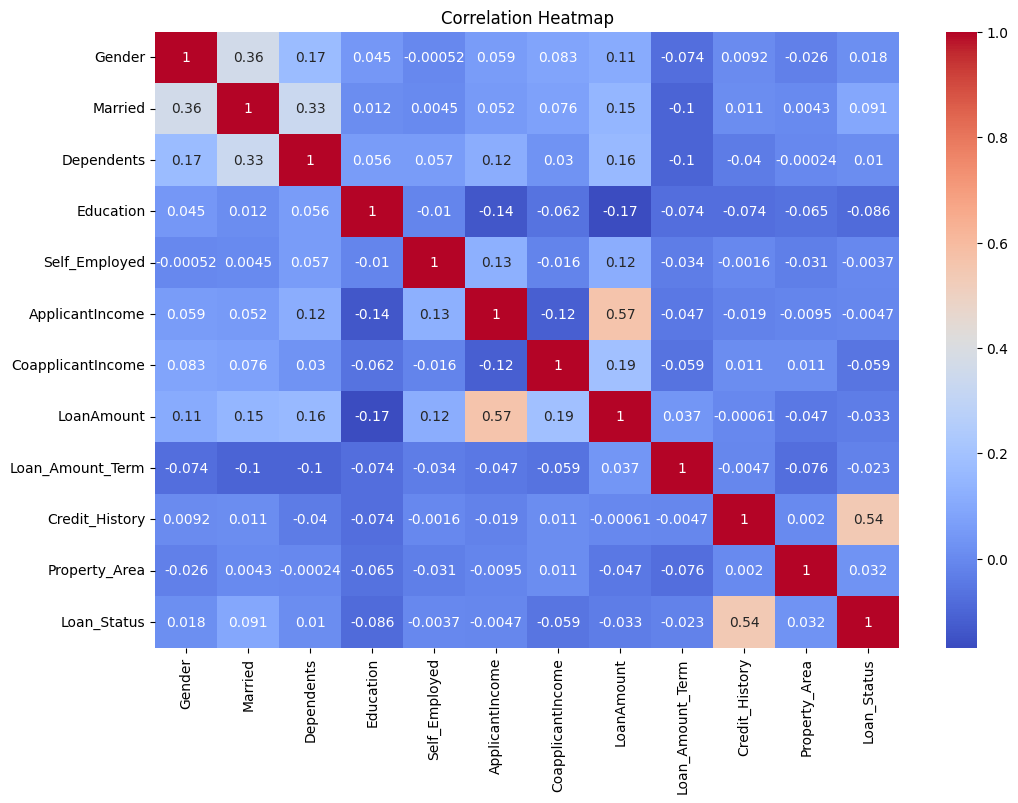

In [17]:
#EDA
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis

The heatmap shows that `Credit_History` has the strongest positive correlation with `Loan_Status` (0.54), indicating that applicants with good credit history are more likely to receive loan approval.

Another strong correlation exists between `ApplicantIncome` and `LoanAmount` (0.57), suggesting that applicants with higher income tend to request larger loan amounts.

In [18]:
# 11. Features and Target
# =========================

X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']


In [19]:
# 12. Train Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.2,
    
    random_state=42
)

In [20]:
# 13. Train Model
# =========================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# =========================
# 14. Prediction
# =========================

y_pred = model.predict(X_test)

# =========================
# 15. Evaluation
# =========================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.7886178861788617


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
# 16. Confusion Matrix
# =========================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[18 25]
 [ 1 79]]


In [22]:
# 17. Classification Report
# =========================

print("Classification Report:")

print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [24]:
# 18. Actual vs Predicted
# =========================

results = pd.DataFrame({
    
    'Actual': y_test,
    
    'Predicted': y_pred
})

print(results.head(20))

     Actual  Predicted
350       1          1
377       1          1
163       1          1
609       1          1
132       1          1
578       1          1
316       1          1
2         1          1
340       0          1
77        0          1
218       0          0
462       1          1
109       1          1
322       1          1
137       1          1
363       1          1
208       1          1
101       1          1
234       1          1
182       1          1


In [25]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6910569105691057


In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7560975609756098


In [27]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5772357723577236
